In [1]:
# Import Required Libraries

import os
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime as dt

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.options.display.max_columns=None
pd.options.display.float_format='{:.2f}'.format

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Check Avilable Date in Kaggle 
os.listdir('/kaggle/input/walmart-sales')

['Walmart_Sales.csv']

In [3]:
# Load Dataset into a Pandas Dataframe
data=pd.read_csv('/kaggle/input/walmart-sales/Walmart_Sales.csv')

In [4]:
# Make a Data Copy 
df=data.copy()

In [5]:
# Check Structure of Data and Number or Rows and Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
# Check for Missing Values
df.isna().sum().sum()

0

In [7]:
# Check for Duplicate Rows
df.duplicated().sum()

0

In [8]:
# Remove Whitespace from Column Names (if any) 
df.columns.str.strip()

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [9]:
# Generate Descriptive Statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.00,23.00,12.99,1.00,12.00,23.00,34.00,45.00
Weekly_Sales,6435.00,1046964.88,564366.62,209986.25,553350.10,960746.04,1420158.66,3818686.45
Holiday_Flag,6435.00,0.07,0.26,0.00,0.00,0.00,0.00,1.00
Temperature,6435.00,60.66,18.44,-2.06,47.46,62.67,74.94,100.14
Fuel_Price,6435.00,3.36,0.46,2.47,2.93,3.44,3.73,4.47
CPI,6435.00,171.58,39.36,126.06,131.74,182.62,212.74,227.23
Unemployment,6435.00,8.00,1.88,3.88,6.89,7.87,8.62,14.31


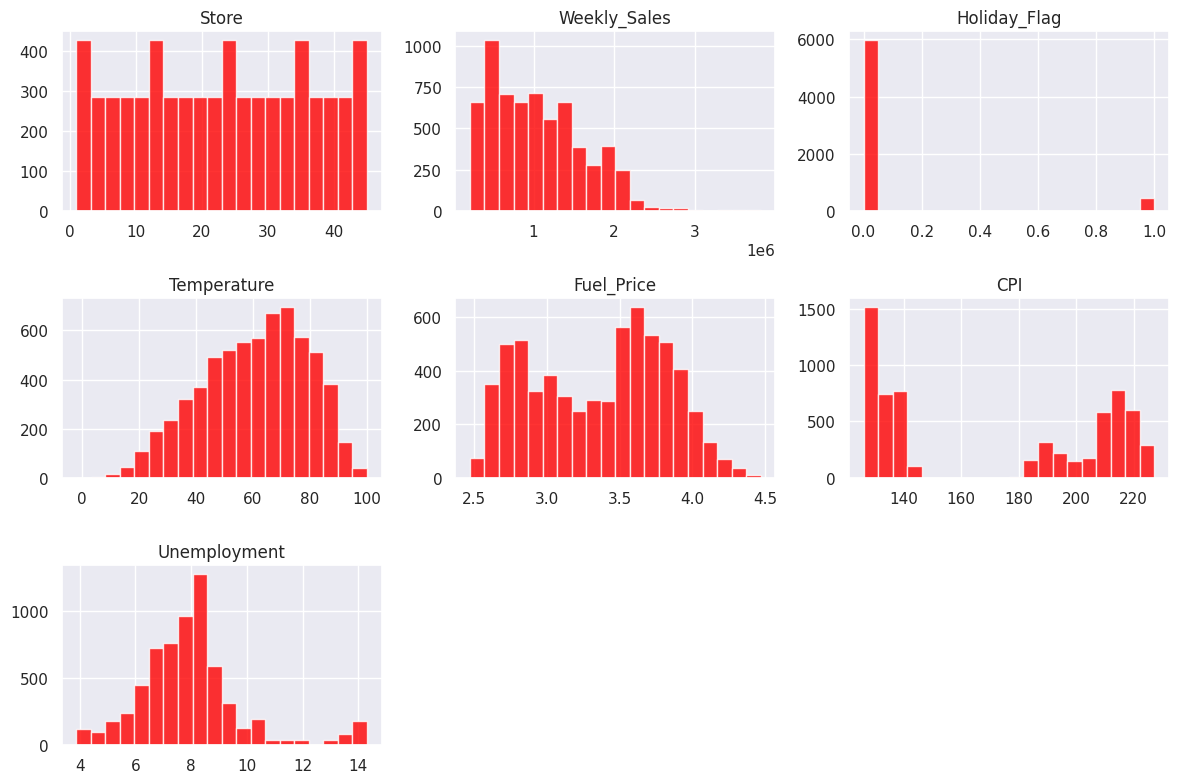

In [10]:
# Visualize Distribution/Histogram of Variables 
df.drop('Date', axis=1).hist(bins=20, figsize=(12,8), alpha=.8, color='red', rwidth=5)
plt.tight_layout()
plt.show();

In [11]:
# Convert Date Type from Object to Datetime 
df['Date']=pd.to_datetime(df.Date, dayfirst=True)

In [12]:
# Create Year and Month Columns from Date Column
df['Year']=df.Date.dt.year
df['Month']=df.Date.dt.month

In [13]:
df['Temperature']=df['Temperature'].astype(int)
df['Weekly_Sales']=df['Weekly_Sales'].astype(int)
df['CPI']=df['CPI'].astype(int)

In [14]:
# Create New Categorical Columns from Continuous Variables For more Analysis and Visualizations

df['Holiday']=np.where(df['Holiday_Flag']==0, 'no', 'yes')

df['Unemp']=pd.qcut(df['Unemployment'], q=4, labels=['very low','low','medium','high'])
df['Cpi']=pd.qcut(df['CPI'], q=4, labels=['very low','low','medium','high'])
df['Temp']=pd.cut(df['Temperature'], bins=[(df['Temperature'].min()-1), 10, 20, 30, 40, df['Temperature'].max()], labels=['very cold', 'cold','mild','warm','hot'], include_lowest=True)
df['Fuel']=pd.qcut(df['Fuel_Price'], q=4, labels=['cheap','reasonable','expensive','very expensive'])

In [15]:
# Display the Data after Creating New Columns
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Holiday,Unemp,Cpi,Temp,Fuel
0,1,2010-02-05,1643690,0,42,2.57,211,8.11,2010,2,no,medium,medium,hot,cheap
1,1,2010-02-12,1641957,1,38,2.55,211,8.11,2010,2,yes,medium,medium,warm,cheap
2,1,2010-02-19,1611968,0,39,2.51,211,8.11,2010,2,no,medium,medium,warm,cheap
3,1,2010-02-26,1409727,0,46,2.56,211,8.11,2010,2,no,medium,medium,hot,cheap
4,1,2010-03-05,1554806,0,46,2.62,211,8.11,2010,3,no,medium,medium,hot,cheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173,0,64,4.00,192,8.68,2012,9,no,high,medium,hot,very expensive
6431,45,2012-10-05,733455,0,64,3.98,192,8.67,2012,10,no,high,medium,hot,very expensive
6432,45,2012-10-12,734464,0,54,4.00,192,8.67,2012,10,no,high,medium,hot,very expensive
6433,45,2012-10-19,718125,0,56,3.97,192,8.67,2012,10,no,high,medium,hot,very expensive


In [16]:
# Grouping Object(Categorical) and Numeric Variables/Columns
obj=df[['Holiday', 'Unemp', 'Cpi', 'Temp', 'Fuel']]
num=df[['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature','Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month']]

In [17]:
# Outliers Detection
for col in num.columns[:-2]:
    q1, q3 =df[col].quantile([0.25,0.75])
    iqr=q3-q1
    low, upp= q1-1.5*iqr, q3+1.5*iqr
    no_outliers=df[(df[col]<low)|(df[col]>upp)].shape[0]
    print(f'\n {col}: {no_outliers} Outliers')
    print(f'\n {df[col].value_counts().reset_index().sort_values(col, ascending=False)[:5]}')  # This Code to get the highest repeated values to make sure if this a real outlier or not
    print(f'\n Max {col}: {df[col].max():.2f}')
    print(f' Min {col}: {df[col].min():.2f}')
    print(f' Unique Values of {col}= {df[col].nunique()}')
    print("::" *45)


 Store: 0 Outliers

     Store  count
44     45    143
20     44    143
19     43    143
18     42    143
17     41    143

 Max Store: 45.00
 Min Store: 1.00
 Unique Values of Store= 45
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 Weekly_Sales: 34 Outliers

       Weekly_Sales  count
5653       3818686      1
4996       3766687      1
3992       3749057      1
4794       3676388      1
5945       3595903      1

 Max Weekly_Sales: 3818686.00
 Min Weekly_Sales: 209986.00
 Unique Values of Weekly_Sales= 6424
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 Holiday_Flag: 450 Outliers

    Holiday_Flag  count
1             1    450
0             0   5985

 Max Holiday_Flag: 1.00
 Min Holiday_Flag: 0.00
 Unique Values of Holiday_Flag= 2
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 Temperature: 3 Outliers

     Temperature  count
90          100      2

In [18]:
# remove outliers
for col in num.columns[:-2]:
    Q1, Q3 =df[col].quantile([0.25,0.75])
    IQR=Q3-Q1
    Low, Upp= Q1-1.5*IQR, Q3+1.5*IQR
    df=df[(df[col]>=Low)&(df[col]<=Upp)]

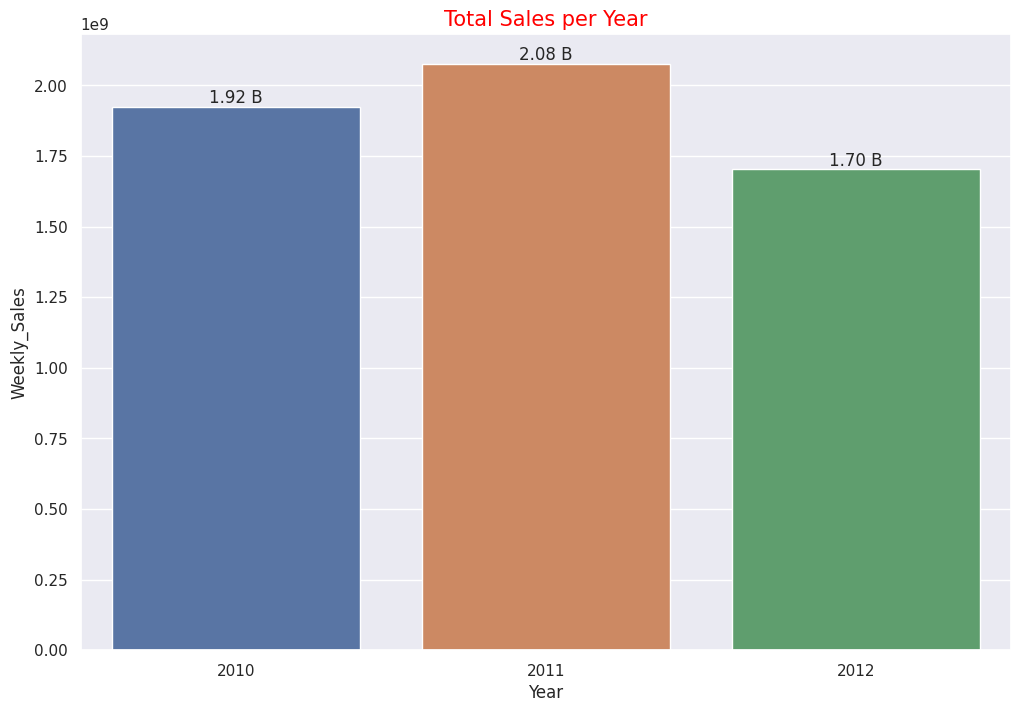

In [19]:
plt.figure(figsize=(12,8))
ax=sns.barplot(data=df, x='Year', y='Weekly_Sales', estimator=sum, errorbar=None)
for bars in ax.containers:
    ax.bar_label(bars, labels=[f'{v.get_height()/1e9:.2f} B' for v in bars])
plt.title('Total Sales per Year', color='red', fontsize=15)
plt.show()

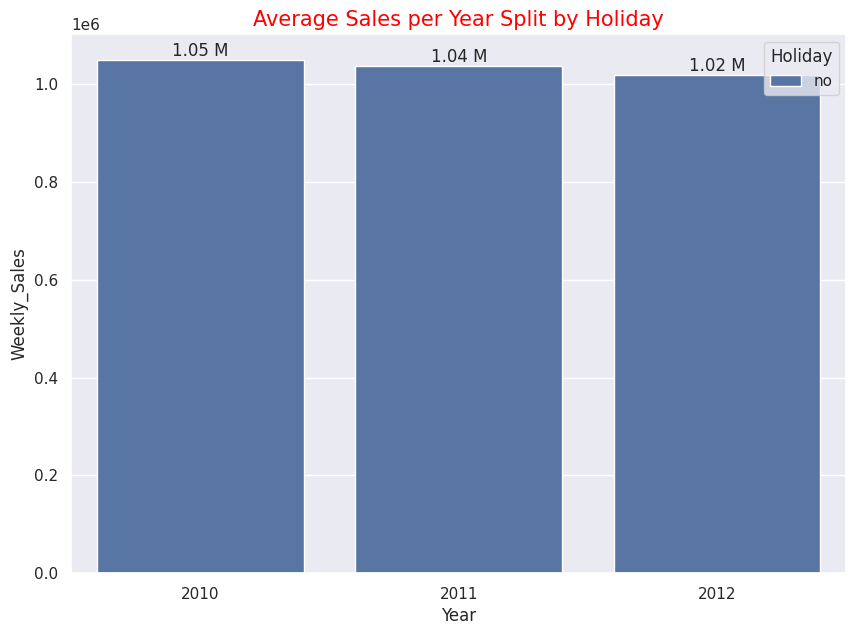

In [20]:
plt.figure(figsize=(10,7))
ax=sns.barplot(data=df, x='Year', hue='Holiday', y='Weekly_Sales', estimator=np.mean, errorbar=None)
for bars in ax.containers:
    ax.bar_label(bars, labels=[f'{v.get_height()/1e6:.2f} M' for v in bars])
plt.title('Average Sales per Year Split by Holiday', color='red', fontsize=15)
plt.show()

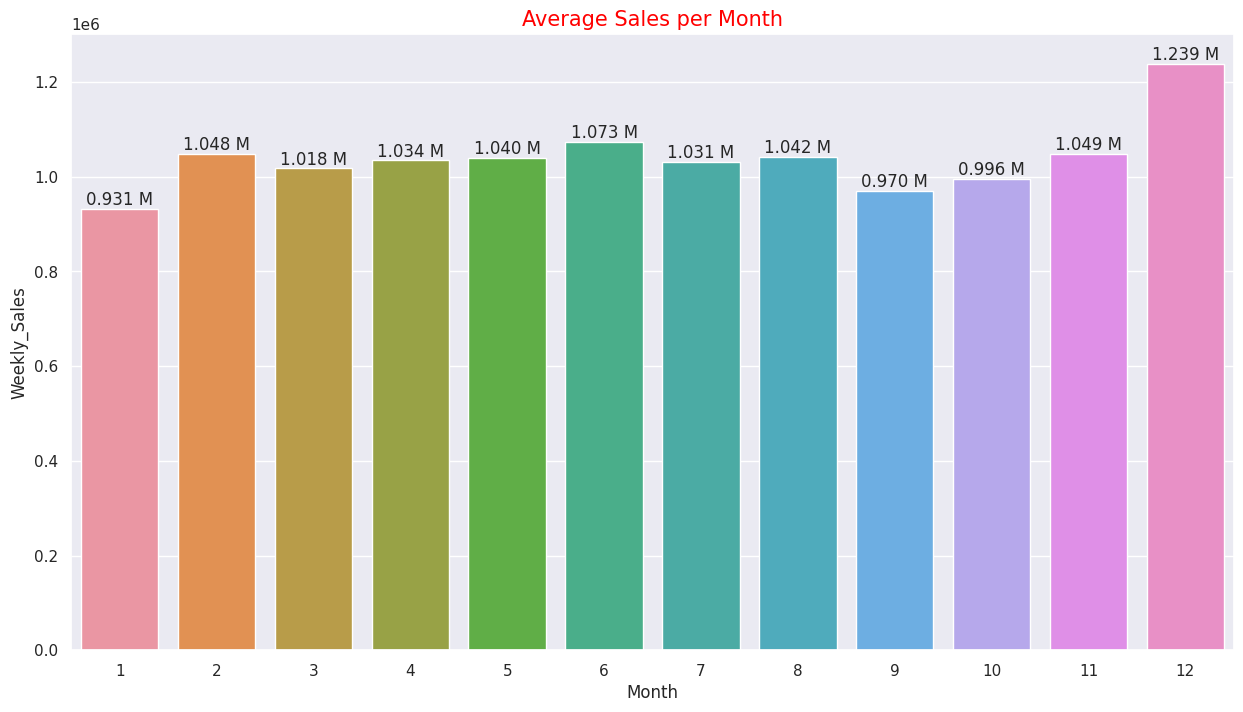

In [21]:
plt.figure(figsize=(15,8))
ax=sns.barplot(data=df, x='Month', y='Weekly_Sales', estimator=np.mean, errorbar=None)
for bars in ax.containers:
    ax.bar_label(bars, labels=[f'{v.get_height()/1e6:.3f} M' for v in bars])
plt.title('Average Sales per Month', color='red', fontsize=15)
plt.show()

In [22]:
# Top 5 Stores DataFrame by Weekly Sales
top_stores=df.groupby('Store', as_index=False)['Weekly_Sales'].mean().sort_values(by='Weekly_Sales', ascending=False)[:5]
top_5stores=df[df['Store'].isin(top_stores['Store'])]
top_5stores

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Holiday,Unemp,Cpi,Temp,Fuel
143,2,2010-02-05,2136989,0,40,2.57,210,8.32,2010,2,no,medium,medium,warm,cheap
145,2,2010-02-19,2124451,0,39,2.51,210,8.32,2010,2,no,medium,medium,warm,cheap
146,2,2010-02-26,1865097,0,46,2.56,210,8.32,2010,2,no,medium,medium,hot,cheap
147,2,2010-03-05,1991013,0,47,2.62,211,8.32,2010,3,no,medium,medium,hot,cheap
148,2,2010-03-12,1990483,0,57,2.67,211,8.32,2010,3,no,medium,medium,hot,cheap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2855,20,2012-09-28,2008350,0,58,4.00,215,7.28,2012,9,no,low,high,hot,very expensive
2856,20,2012-10-05,2246411,0,60,3.98,215,7.29,2012,10,no,low,high,hot,very expensive
2857,20,2012-10-12,2162951,0,47,4.00,216,7.29,2012,10,no,low,high,hot,very expensive
2858,20,2012-10-19,1999363,0,56,3.97,216,7.29,2012,10,no,low,high,hot,very expensive


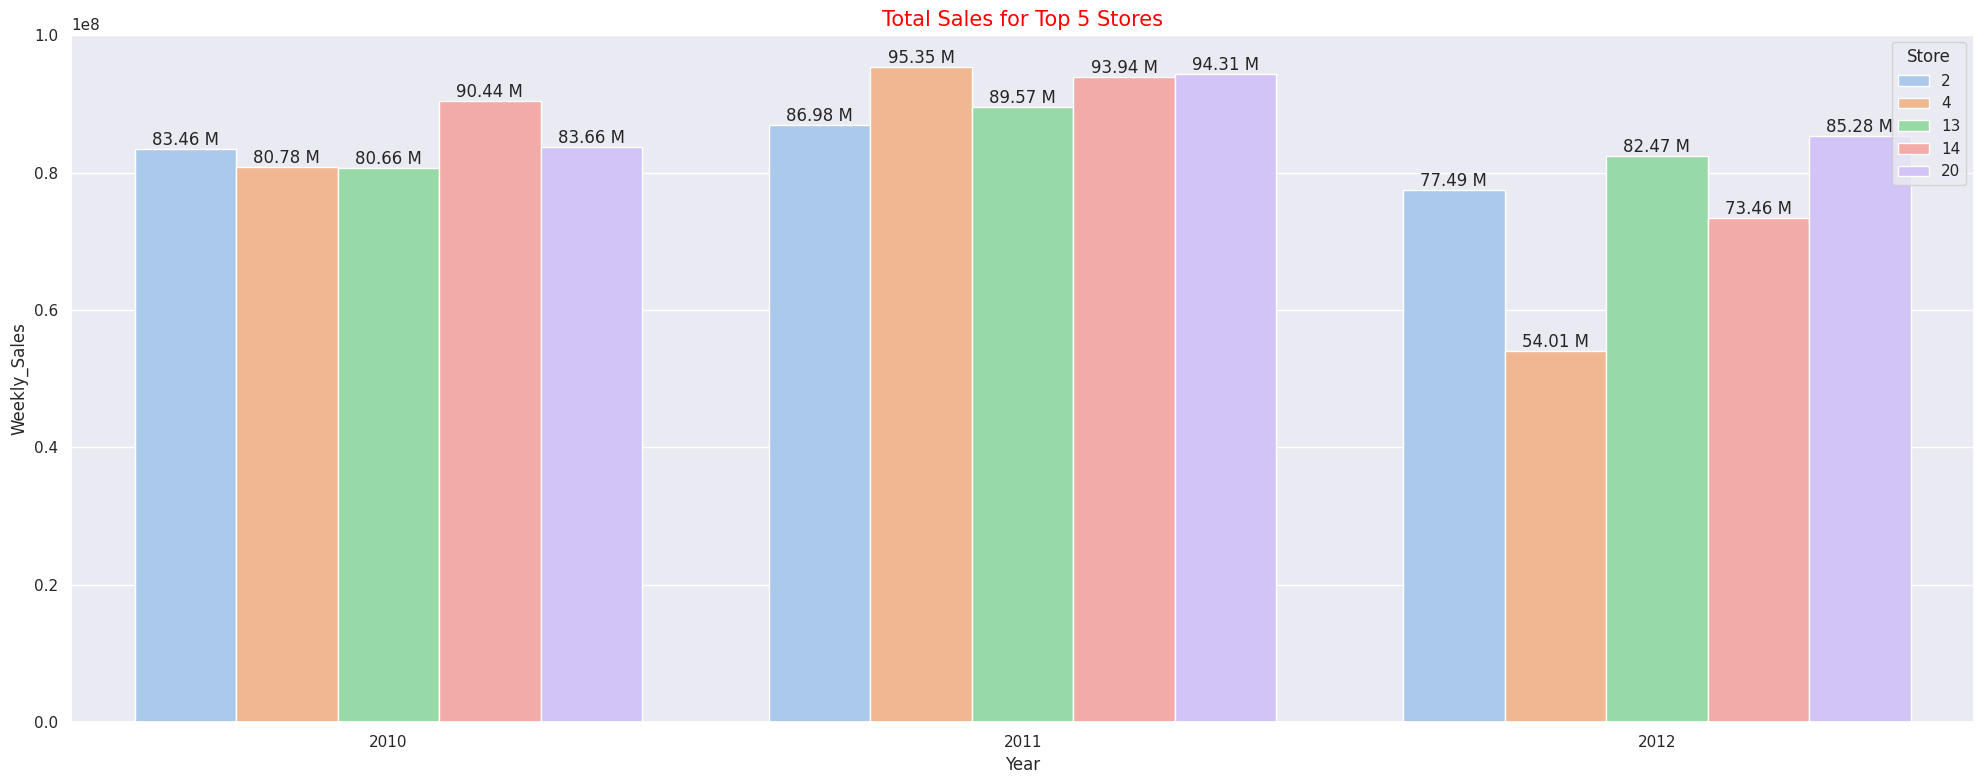

In [23]:
plt.figure(figsize=(20,8))
ax=sns.barplot(data=top_5stores, x='Year', y='Weekly_Sales', hue='Store', palette='pastel', errorbar=None, estimator=sum)
for bars in ax.containers:
    ax.bar_label(bars, labels=[f'{v.get_height()/1e6:.2f} M' for v in bars])
plt.title('Total Sales for Top 5 Stores', color='red', fontsize=15)
plt.tight_layout()
plt.show();

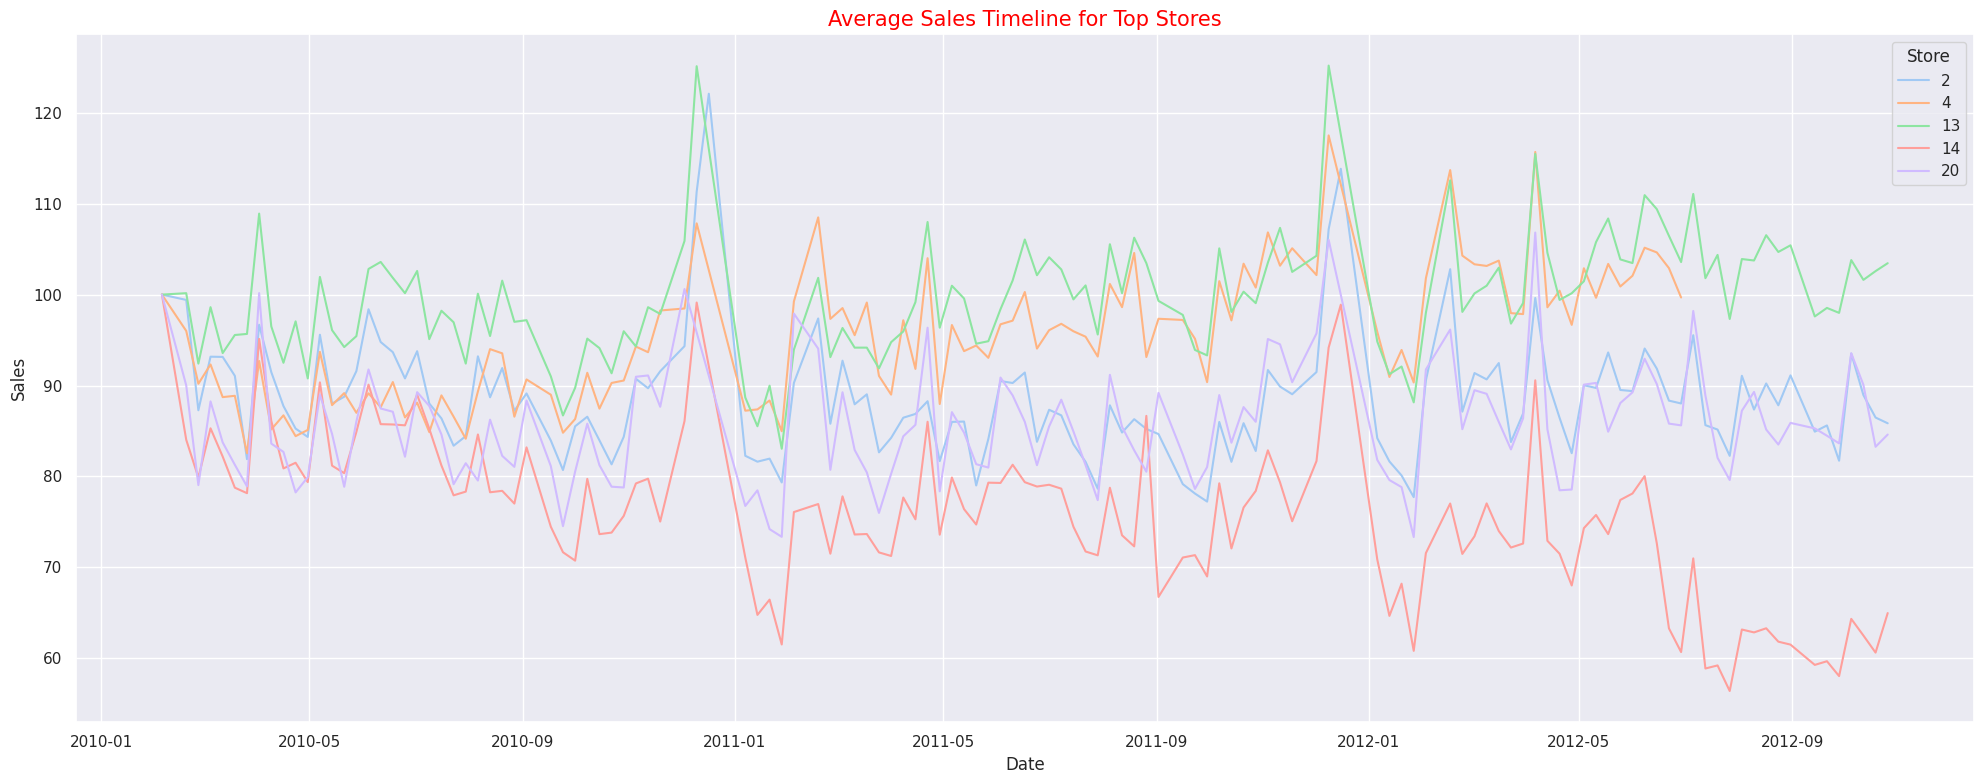

In [24]:
top_5stores=top_5stores.copy()
top_5stores['Sales']=top_5stores.groupby('Store')['Weekly_Sales'].transform(lambda x: x/x.iloc[0]*100)

plt.figure(figsize=(20,8))
sns.lineplot(data=top_5stores, x='Date', y='Sales', hue='Store', palette='pastel')
plt.title('Average Sales Timeline for Top Stores', color='red', fontsize=15)
plt.tight_layout()
plt.show();

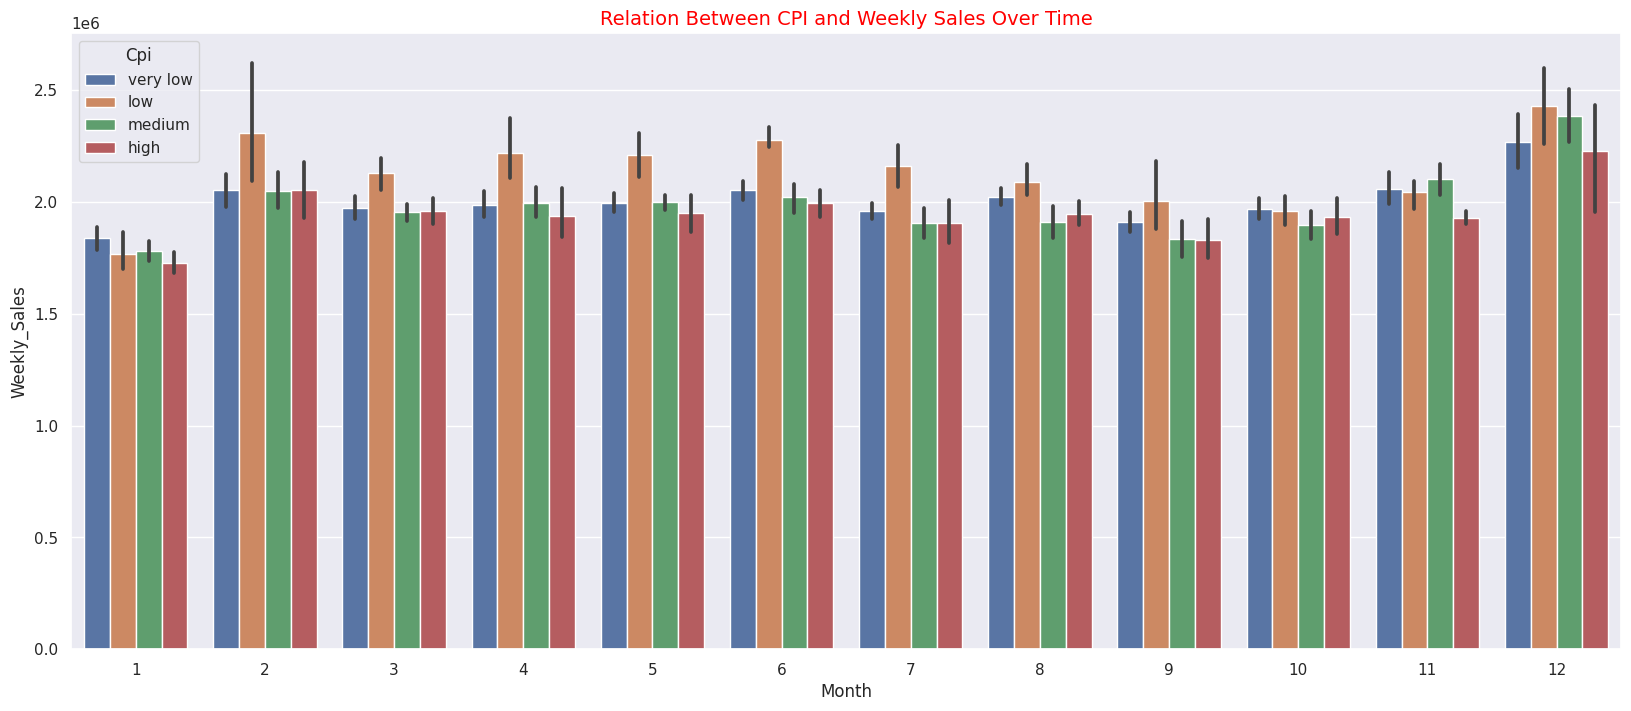

In [25]:
plt.figure(figsize=(20,8))
sns.barplot(data=top_5stores, x='Month', y='Weekly_Sales', hue='Cpi')
plt.title('Relation Between CPI and Weekly Sales Over Time', fontsize=14, color='red');

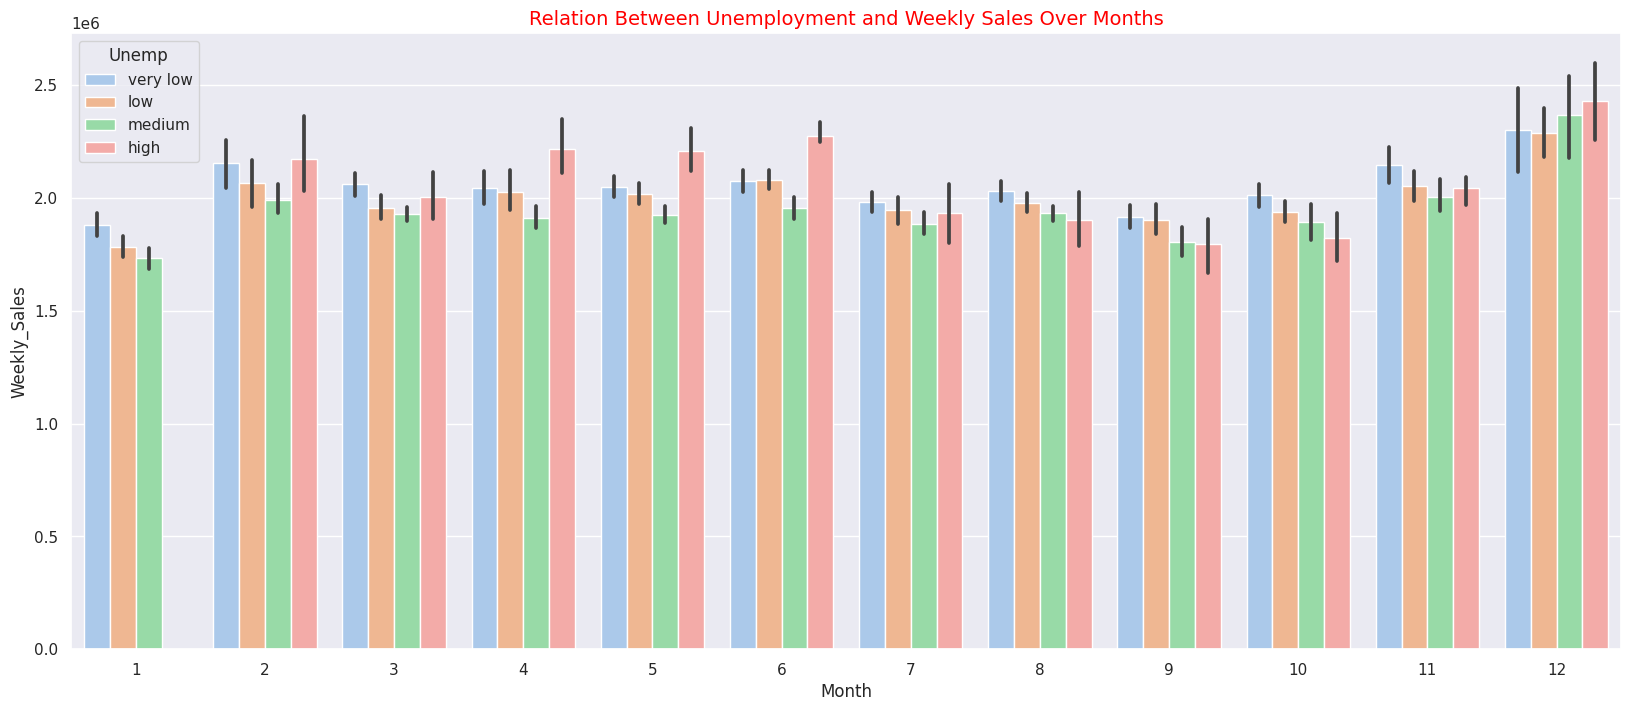

In [26]:
plt.figure(figsize=(20,8))
sns.barplot(data=top_5stores, x='Month', y='Weekly_Sales', hue='Unemp', palette='pastel')
plt.title('Relation Between Unemployment and Weekly Sales Over Months', fontsize=14, color='red');

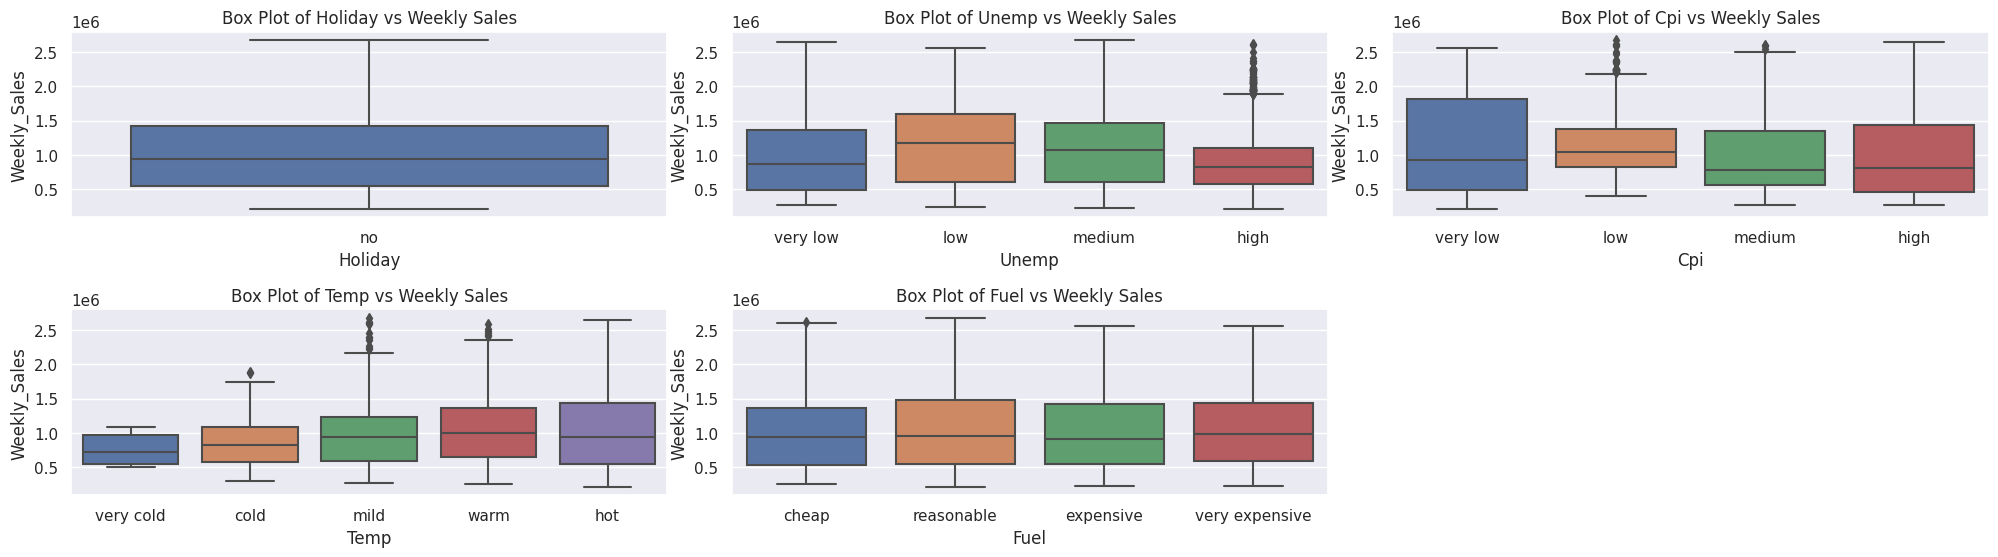

In [27]:
# Categorical Variables Relationships with Weekly Sales
plt.figure(figsize=(20,8))
for ind, col in enumerate(obj):
    top_catgs=df[col].value_counts().index[:20]
    ft=df[df[col].isin(top_catgs)]
    plt.subplot(3,3,1+ind)
    sns.boxplot(x=ft[col], y=ft['Weekly_Sales'])
    plt.title(f'Box Plot of {col} vs Weekly Sales')
plt.tight_layout()
plt.show();

In [28]:
pair_cols=df[['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month']]

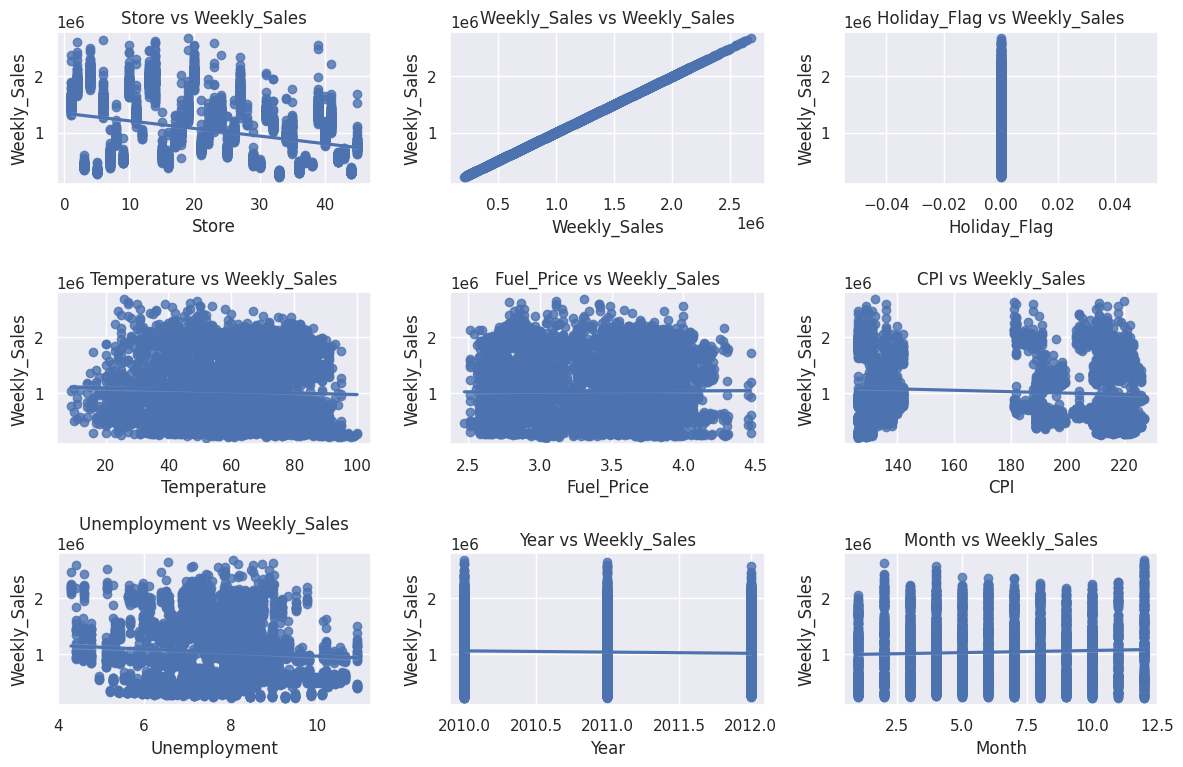

In [29]:
#Pairwise Relationships
df_sample=df.sample(5000, random_state=42)

plt.figure(figsize=(12,8))
for i, col in enumerate(pair_cols, 1):
    plt.subplot(3, 3, i)
    sns.regplot(data=df_sample, x=col, y='Weekly_Sales')
    plt.title(f'{col} vs Weekly_Sales')
plt.tight_layout()
plt.show();

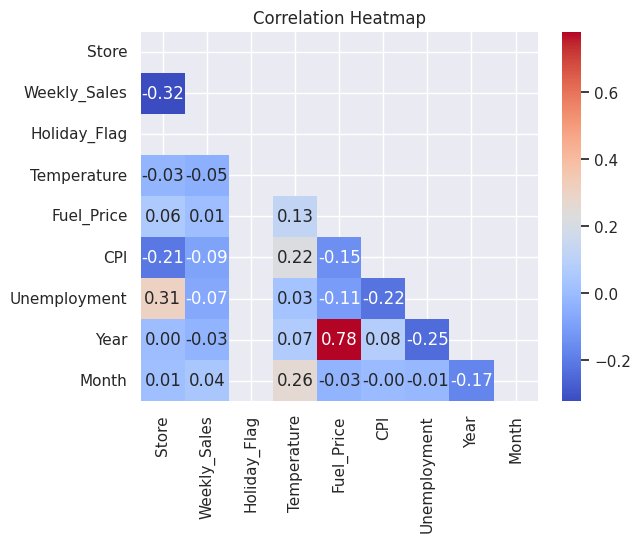

In [30]:
# Heatmap to see which variables are most correlated with each other
corr= df_sample.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, fmt='.2f', cmap='coolwarm', annot=True, mask=mask)
plt.title('Correlation Heatmap');

In [31]:
# OLS Model for Weekly Sales Prediction, Display Coef and P Value, if P Value > .05 it means this factor is not significant
x=df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month']]
y=df['Weekly_Sales']

model=sm.OLS(y,x).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:           Weekly_Sales   R-squared (uncentered):                   0.809
Model:                            OLS   Adj. R-squared (uncentered):              0.809
Method:                 Least Squares   F-statistic:                              3329.
Date:                Thu, 09 Oct 2025   Prob (F-statistic):                        0.00
Time:                        08:01:21   Log-Likelihood:                         -80213.
No. Observations:                5507   AIC:                                  1.604e+05
Df Residuals:                    5500   BIC:                                  1.605e+05
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

# Make Store a Categorical Variable (C(Store)), to Get the Impact of Each Store on Weekly Sales
model=smf.ols('Weekly_Sales ~ C(Store) + Holiday_Flag + Temperature + Fuel_Price + CPI + Unemployment + Year + Month',data=df).fit()
model.summary()

In [32]:
# Prediction on Weekly Sales for a Store with Specific Variables
new_data = pd.DataFrame([{'Store': 10,'Holiday_Flag': 0,'Temperature': 50,'Fuel_Price': 3.5,'CPI': 220,'Unemployment': 8, 'Year': 2011,'Month': 12}])
pred_price = model.predict(new_data)
print(f"Predicted Weekly Sales = ${pred_price[0]:,.2f}")

Predicted Weekly Sales = $1,208,463.32


In [33]:
# Comparison between Predicted Sales and Actual Sales
df["Predicted_Sales"] = model.predict(x)
print(df[["Weekly_Sales", "Predicted_Sales"]].head(10))

# Calculate accuracy measures
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(df["Weekly_Sales"], df["Predicted_Sales"])
rmse = np.sqrt(mean_squared_error(df["Weekly_Sales"], df["Predicted_Sales"]))
mape = np.mean(np.abs((df["Weekly_Sales"] - df["Predicted_Sales"]) / df["Weekly_Sales"])) * 100

print(f"\nMean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

    Weekly_Sales  Predicted_Sales
0        1643690       1243453.35
2        1611968       1245184.83
3        1409727       1238820.26
4        1554806       1250676.75
5        1439541       1239836.98
6        1472515       1244489.38
7        1404429       1248062.87
8        1594968       1246782.98
9        1545418       1244867.30
10       1466058       1244781.35

Mean Absolute Error (MAE): 429,631.92
Root Mean Squared Error (RMSE): 512,303.56
Mean Absolute Percentage Error (MAPE): 61.51%


In [34]:
# OLS regression is better for explanation and providing statistical description than prediction — error rate here is too high.

In [35]:
# New Data for More Than One Store
new_data = pd.DataFrame([{'Store': 1, 'Holiday_Flag': 0, 'Temperature': 45, 'Fuel_Price': 3.2, 'CPI': 210, 'Unemployment': 7, 'Year': 2011, 'Month': 5},
                         {'Store': 5, 'Holiday_Flag': 1, 'Temperature': 30, 'Fuel_Price': 3.8, 'CPI': 230, 'Unemployment': 6, 'Year': 2012, 'Month': 12},
                         {'Store': 10, 'Holiday_Flag': 0, 'Temperature': 50, 'Fuel_Price': 3.5, 'CPI': 220, 'Unemployment': 8, 'Year': 2011, 'Month': 12}])

pred_prices = model.predict(new_data)
for i, price in enumerate(pred_prices):
    print(f"Predicted Weekly Sales for row {i+1} = ${price:,.2f}")

Predicted Weekly Sales for row 1 = $1,285,613.17
Predicted Weekly Sales for row 2 = $1,285,132.25
Predicted Weekly Sales for row 3 = $1,208,463.32


In [36]:
df.to_csv('/kaggle/working/Walmart_Sales.csv', index=False)